In [1]:
import geopandas as gpd
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape, box
import os
from glob import glob
import pandas as pd
import numpy as np
import pandapower as pp
import sys

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image
import matplotlib.cm as cm
from rasterstats import zonal_stats

from pandapower.plotting import pf_res_plotly
import plotly.io as pio
import copy

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from power_flow import build_pandapower_model

load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\zlib1.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\abseil_dll.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\utf8_validity.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\re2.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\libprotobuf.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\highs.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\ortools.dll...


#### Read power network data

In [2]:
# === Read power network data ===
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')

basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

tc_path = '../data/tc/tc_yagi.tif'
# flood_path = '../data/flood/'

#### Read fragility curves

In [3]:
# === Read fragility curves ===
def load_curves(curve_path, sheet_name=None):
    # 先读取前5行用于获取正确的列名（ID number 行）
    raw = pd.read_excel(curve_path, sheet_name=sheet_name, nrows=5)
    
    # 用第1列为 index（即 'Wind speed (m/s)'），第2~n列为 curve ID
    id_row = raw.iloc[0, 1:]  # “ID number” 行，作为列名
    id_row.index = range(1, len(id_row)+1)

    # 读取真正的数据，从第6行开始
    df = pd.read_excel(curve_path, sheet_name=sheet_name, skiprows=5)

    # 将列名替换为 ['Wind speed', ID1, ID2, ...]
    df.columns = ['Wind speed'] + list(id_row)

    # 保证所有数值列都是 float
    df = df.apply(pd.to_numeric, errors='coerce')

    # # design wind speed (dws)
    # dws = 44
    # # shift design wind speed of all curves to 60 m/s
    # scaling_factor = dws / 60
    # curves = curves.apply(lambda x: x * scaling_factor if pd.api.types.is_numeric_dtype(x) else x)

    #interpolate the curves to fill missing values
    # curves = curves.interpolate()
    return df
    
curve_path = '../data/fragility_curves.xlsx'
curves = load_curves(curve_path, sheet_name='test') # wind_curves_test

curves.head()

,Wind speed,W1,W3.15,W3.45,W6.1,W6.2
0,0,0,0.000000e+00,0.0,0.000000e+00,0.0
1,1,0,0.000000e+00,0.0,1.250000e-16,0.0
2,2,0,3.549661e-278,0.0,1.326058e-13,0.0
3,3,0,4.069272e-221,0.0,7.806489e-12,0.0
4,4,0,1.242419e-184,0.0,1.406744e-10,0.0


In [4]:
# # === Load wind speed map (geotiff) ===
# def load_tc(tif_path, speed_threshold=0):
#     with rasterio.open(tif_path) as src:
#         band1 = src.read(1)
#         mask = band1 > speed_threshold
#         transform = src.transform
#         geoms = (
#             shape(geom) for geom, val in shapes(band1, mask=mask, transform=transform)
#             if val > speed_threshold
#         )
#         gdf = gpd.GeoDataFrame(geometry=list(geoms), crs=src.crs)
#     return gdf.to_crs("EPSG:32648")

# # === Load flood extent (shapefile) ===
# def load_flood(folder_path):
#     all_shps = glob(os.path.join(folder_path, "*.shp"))
#     gdfs = [gpd.read_file(shp).to_crs("EPSG:32648") for shp in all_shps]
#     return gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

# tc_gdf = load_tc(tc_path)
# flood_gdf = load_flood(flood_path)

#### Create TC map

Min/Max wind raster value: 0.0 58.606785
--------------------
CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Width, Height: 121 111
Number of Bands: 1
Transform: | 0.10, 0.00, 102.95|
| 0.00,-0.10, 26.05|
| 0.00, 0.00, 1.00|
NoData Value: None
Band 1 shape: (111, 121)
Band 1 min: 0.0
Band 1 max: 58.606785
Band 1 mean: 6.845121


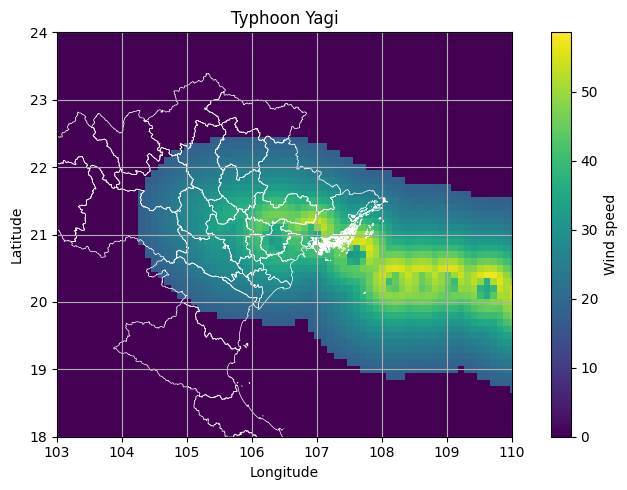

In [5]:
with rasterio.open(tc_path) as src:
    wind_speed = src.read(1)
    print("Min/Max wind raster value:", np.nanmin(wind_speed), np.nanmax(wind_speed))
    print("--------------------")

    transform = src.transform

    print("CRS:", src.crs)
    print("Width, Height:", src.width, src.height)
    print("Number of Bands:", src.count)
    print("Transform:", src.transform)
    print("NoData Value:", src.nodata)

    print("Band 1 shape:", wind_speed.shape)
    print("Band 1 min:", np.min(wind_speed))
    print("Band 1 max:", np.max(wind_speed))
    print("Band 1 mean:", np.mean(wind_speed))

    basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")
    basemap = basemap.to_crs("EPSG:4326")

    left = transform[2]
    top = transform[5]
    right = left + transform[0] * src.width
    bottom = top + transform[4] * src.height

    extent = (left, right, bottom, top)

    fig, ax = plt.subplots(figsize=(8, 5))
    img = ax.imshow(wind_speed, cmap="viridis", extent=extent, origin='upper')
    plt.colorbar(img, ax=ax, label="Wind speed")
    basemap.plot(ax=ax, color='none', edgecolor='white', linewidth=0.5, zorder=1)

    ax.set_title("Typhoon Yagi")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(103, 110)
    ax.set_ylim(18, 24)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig("../figures/hazard_figures/yagi_map.png")
    plt.show()

#### Assign wind speed to each asset

In [5]:
def extract_point_wind_speed(gdf, src):
    """
        gdf: infrastructure vector data
        src: hazard map raster data
    """
    gdf = gdf.to_crs(src.crs)

    # 获取点的坐标
    coords = [(geom.x, geom.y) for geom in gdf.geometry]
    values = list(src.sample(coords))
    nodata = src.nodata

    # 提取风速值（注意处理nodata）
    wind_speeds = [v[0] if v[0] != nodata else 0 for v in values]
    gdf["wind_speed"] = wind_speeds
    return gdf

def extract_zonal_wind_speed(gdf, src, stats_method="max"):
    gdf = gdf.to_crs(src.crs)

    # 读取风速数据和transform信息
    wind_speed = src.read(1)
    transform = src.transform
    nodata = src.nodata

    # 处理 nodata
    if nodata is not None:
        wind_speed = np.where(wind_speed == nodata, 0, wind_speed)

    # 进行 zonal stats
    stats = zonal_stats(gdf, wind_speed, affine=transform, stats=stats_method)
    # print(stats[:5])

    gdf["wind_speed"] = [s[stats_method] if s[stats_method] is not None else 0 for s in stats]
    return gdf

In [6]:
def wind_speed_extraction(gdf, tif_path, stats_method="max"):
    with rasterio.open(tif_path) as src:
        results = []

        # 将不同类型的geometry分开处理
        print(gdf.geometry.geom_type.unique())
        for geom_type in gdf.geometry.geom_type.unique():
            sub_gdf = gdf[gdf.geometry.geom_type == geom_type].copy()

            if sub_gdf.empty:
                continue
            
            print(f"Processing {len(sub_gdf)} {geom_type}s...")
            
            sub_gdf = sub_gdf.to_crs(src.crs)

            if geom_type == "Point":
                sub_gdf = extract_point_wind_speed(sub_gdf, src)
            elif geom_type in ["LineString", "MultiLineString", "Polygon", "MultiPolygon"]:
                sub_gdf = extract_zonal_wind_speed(sub_gdf, src, stats_method=stats_method)
            else:
                print(f"Unsupported geometry type: {geom_type}, skipping...")
                continue

            results.append(sub_gdf)

        # 合并所有结果
        if results:
            return pd.concat(results, ignore_index=True)
        else:
            raise ValueError("No supported geometries found.")

In [7]:
lines_gdf_wind = wind_speed_extraction(lines_gdf, tc_path)
nodes_gdf_wind = wind_speed_extraction(nodes_gdf, tc_path)

['LineString']
Processing 6914 LineStrings...


c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


['Point']
Processing 3821 Points...


In [9]:
# nodes_gdf['substation'] = nodes_gdf['OriginalID'].astype(int) > 99999
# nodes_gdf.head()

In [10]:
nodes_gdf_wind.head()

,NodeID,voltage,lon,lat,lines_count,cables_count,capacity,OriginalID,disconnected,geometry,wind_speed
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,8,48,14400,153608703.0,no,POINT (106.06478 20.93373),40.603729
1,NODEVN0003a,220.0,682154.017051,2.315888e+06,12,120,36000,4.0,no,POINT (106.75171 20.93445),39.775883
2,NODEVN3273a,110.0,684889.726446,2.304274e+06,7,39,13500,241065371.0,no,POINT (106.77678 20.82928),40.078110
3,NODEVN3273b,220.0,684710.914392,2.304283e+06,7,39,13500,241065371.0,no,POINT (106.77506 20.82938),40.078110
4,NODEVN3308,220.0,810022.256590,1.417833e+06,2,6,3000,400413519.0,no,POINT (107.85566 12.80995),0.000000


#### Monte carlo simulation

In [8]:
from scipy.interpolate import interp1d

def monte_carlo_simulation(gdf, curves, dam_class, num_iterations=5):
    """
        gdf: the geodataframe containing the asset data
        curves: fragility curves DataFrame containing failure probabilities
        dam_class: can be 'Bus' or 'Line' to specify asset type
        num_iterations: number of Monte Carlo simulations
    """
    
    # Filter real substations from buses (substations + virtual buses)
    # Ensure that the substation column exists and is initialized
    if dam_class == 'Bus' and 'substation' not in gdf.columns:
        # If 'substation' column does not exist, create it based on the OriginalID
        gdf['substation'] = gdf['OriginalID'].astype(int) > 99999

    simulation_result = gdf.copy()

    # 每次迭代创建新的 failure 列
    for iteration in range(num_iterations):
        fail_column = f'fail_iter_{iteration+1}'
        failures = []

        for i in range(len(simulation_result)):
            row = simulation_result.iloc[i]
            wind_speed = row['wind_speed']

            # === Choose fragility curve ID ===
            if dam_class == 'Line':
                if row['voltage'] == 110.0:
                    curve_id = 'W6.1'
                elif row['voltage'] in [220.0, 500.0]:
                    curve_id = 'W6.2'
                else:
                    raise ValueError(f"Unsupported voltage for Line: {row['voltage']}")

            elif dam_class == 'Bus':
                if row['substation'] == True:
                    curve_id = 'W1'
                else:
                    if row['voltage'] in [110.0, 220.0]:
                        curve_id = 'W3.15'
                    elif row['voltage'] == 500.0:
                        curve_id = 'W3.45'
                    else:
                        raise ValueError(f"Unsupported voltage for Bus: {row['voltage']}")
            else:
                raise ValueError(f"Unsupported dam_class: {dam_class}")

            # === 插值并抽样 ===
            frag_curve = curves[["Wind speed", curve_id]]
            interp_func = interp1d(frag_curve["Wind speed"], frag_curve[curve_id], kind='linear', fill_value='extrapolate')
            fail_prob = interp_func(wind_speed)
            rand_num = np.random.uniform(0, 1)
            failures.append(1 if rand_num <= fail_prob else 0)

        simulation_result[fail_column] = failures

    return simulation_result

lines_gdf_sim = monte_carlo_simulation(lines_gdf_wind, curves, 'Line', num_iterations=2)
nodes_gdf_sim = monte_carlo_simulation(nodes_gdf_wind, curves, 'Bus', num_iterations=2)

In [12]:
nodes_gdf_sim.head()

,NodeID,voltage,lon,lat,lines_count,cables_count,capacity,OriginalID,disconnected,geometry,wind_speed,substation,fail_iter_1,fail_iter_2
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,8,48,14400,153608703.0,no,POINT (106.06478 20.93373),40.603729,True,0,0
1,NODEVN0003a,220.0,682154.017051,2.315888e+06,12,120,36000,4.0,no,POINT (106.75171 20.93445),39.775883,False,0,0
2,NODEVN3273a,110.0,684889.726446,2.304274e+06,7,39,13500,241065371.0,no,POINT (106.77678 20.82928),40.078110,True,0,0
3,NODEVN3273b,220.0,684710.914392,2.304283e+06,7,39,13500,241065371.0,no,POINT (106.77506 20.82938),40.078110,True,0,0
4,NODEVN3308,220.0,810022.256590,1.417833e+06,2,6,3000,400413519.0,no,POINT (107.85566 12.80995),0.000000,True,0,0


In [13]:
from matplotlib.ticker import MaxNLocator

def plot_failure_probability_map(simulation_results, basemap, output_path=None):
    simulation_results = simulation_results.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    # Define target regions to show on the map
    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    # 计算 failure_probability（如果还没算）
    fail_cols = [col for col in simulation_results.columns if col.startswith('fail_iter_')]
    if 'failure_probability' not in simulation_results.columns:
        simulation_results['failure_probability'] = simulation_results[fail_cols].mean(axis=1)

    failed = simulation_results[simulation_results['failure_probability'] > 0]
    non_failed = simulation_results[simulation_results['failure_probability'] == 0]

    cmap = cm.Reds
    norm = mcolors.Normalize(vmin=0, vmax=1)

    fig, ax = plt.subplots(figsize=(8,6))

    # ax.set_title("Failure Probability - Red River Delta", fontsize=15)
    ax.set_xlim(105.2, 107.6)
    ax.set_ylim(19.85, 21.7)
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.set_aspect('auto')
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # 叠加背景地图
    target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
    other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)

    # 判断是否为点数据，若是点数据，使用 scatter
    if simulation_results.geometry.iloc[0].geom_type == 'Point':  # 点数据
        # 绘制 failure_probability == 0 的点（灰色底图）
        if not non_failed.empty:
            ax.scatter(non_failed.geometry.x, non_failed.geometry.y, 
                       s=non_failed['failure_probability'].apply(lambda x: max(x * 100, 10)),  # 设置最小点大小
                       c='lightgreen',  # 固定颜色
                       alpha=0.5,  # 设置透明度
                       zorder=2, label='Failure p = 0')

        # 绘制 failure_probability > 0 的点（渐变色）
        if not failed.empty:
            ax.scatter(failed.geometry.x, failed.geometry.y, 
                       s=failed['failure_probability'] * 10,  # 控制点的大小
                       c=failed['failure_probability'],  # 设置颜色映射
                       cmap=cmap, 
                       norm=norm,
                       alpha=0.7,  # 设置透明度
                       zorder=3)
    
    # 如果是线数据，使用 plot
    elif simulation_results.geometry.iloc[0].geom_type == 'LineString':  # 线数据
        # 绘制 failure_probability == 0 的线路（灰色底图）
        if not non_failed.empty:
            non_failed.plot(ax=ax, color='lightgreen', linewidth=0.4, zorder=2, alpha=0.5, label='Failure p = 0')

        # 绘制 failure_probability > 0 的线路（渐变色）
        if not failed.empty:
            failed.plot(ax=ax,
                        column='failure_probability',
                        cmap=cmap,
                        norm=norm,
                        linewidth=1.3,
                        zorder=3)

    # 添加共享 colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", location='right', fraction=0.07, pad=0.04, aspect=20)
    cbar.set_label("Failure probability", fontsize=12)

    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches="tight")
        print(f"Saved to {output_path}")
    
    plt.show()

Saved to ../figures/hazard_figures/failure_probability_map_lines.png


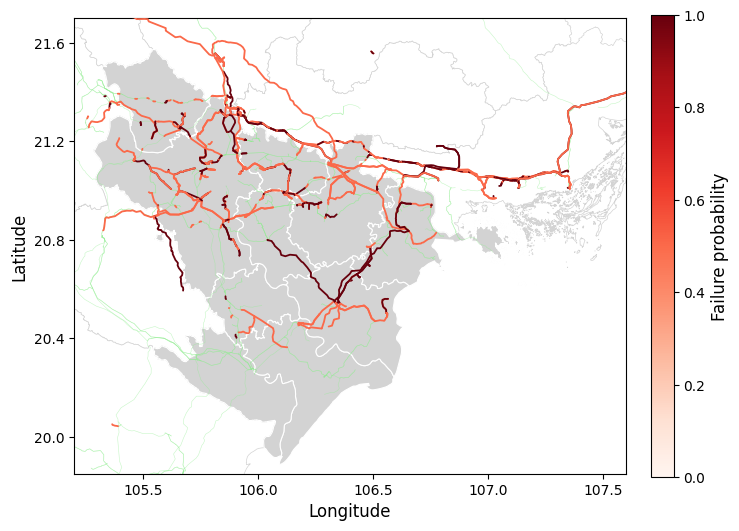

In [14]:
plot_failure_probability_map(lines_gdf_sim, basemap, output_path="../figures/hazard_figures/failure_probability_map_lines.png")

Saved to ../figures/hazard_figures/failure_probability_map_nodes.png


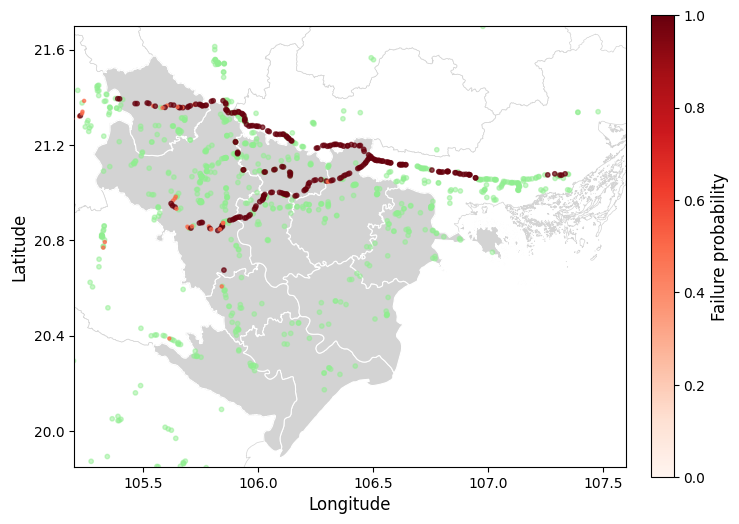

In [15]:
plot_failure_probability_map(nodes_gdf_sim, basemap, output_path="../figures/hazard_figures/failure_probability_map_nodes.png")

In [ ]:
# def simulate_percolation_with_powerflow_and_loadstatus(
#     nodes_gdf, lines_gdf, gens_gdf, loads_gdf, num_iterations=10
#     ):

#     base_net = build_pandapower_model(nodes_gdf, lines_gdf, gens_gdf, loads_gdf)
#     all_buses = base_net.bus.index.tolist()
#     results = []
#     load_status_records = []
#     failed_buses_records = []
#     failed_lines_records = []  # To store failed lines

#     for i in range(num_iterations):
#         fail_col = f"fail_iter_{i+1}"

#         net = copy.deepcopy(base_net)
#         # net.bus["in_service"] = True
#         # net.line["in_service"] = True
        
#         # Fail buses based on 'fail_iter_' column being 0
#         failed_buses = nodes_gdf[nodes_gdf[fail_col] == 0]["NodeID"].tolist()
#         # net.bus.loc[failed_buses, "in_service"] = False
#         valid_failed_buses = [fb for fb in failed_buses if fb in net.bus['name'].values]
#         net.bus.loc[net.bus['name'].isin(valid_failed_buses), "in_service"] = False

#         for fb in valid_failed_buses:
#             failed_buses_records.append({
#                 "iteration": i,
#                 "bus_index": fb  # net.bus.loc[failed_buses, "name"]
#             })

#         # Fail lines based on 'fail_iter_' column being 0
#         failed_lines = lines_gdf[lines_gdf[fail_col] == 0]["LineID"].tolist()
#         # net.line.loc[failed_lines, "in_service"] = False
#         valid_failed_lines = [line_id for line_id in failed_lines if line_id in net.line["name"].values]
#         net.line.loc[net.line["name"].isin(valid_failed_lines), "in_service"] = False

#         # Track the failed lines
#         for line_id in valid_failed_lines:
#             line_data = lines_gdf.loc[lines_gdf["LineID"] == line_id]
#             failed_lines_records.append({
#                 "iteration": i,
#                 "line_index": line_id,
#                 "from_bus": line_data["fromNode"].values[0],
#                 "to_bus": line_data["toNode"].values[0]
#             })

#         # # Fail lines based on failed buses
#         # for idx, line in net.line.iterrows():
#         #     if not net.bus.loc[line["from_bus"], "in_service"] or not net.bus.loc[line["to_bus"], "in_service"]:
#         #         net.line.at[idx, "in_service"] = False
#         #         failed_lines.append((line["from_bus"], line["to_bus"]))

#         # # Track the failed lines
#         # for fl in failed_lines:
#         #     failed_lines_records.append({
#         #         "iteration": i,
#         #         "from_bus": fl[0],
#         #         "to_bus": fl[1]
#         #     })

#         try:
#             G = top.create_nxgraph(net, include_switches=True)
#             comps = list(top.connected_components(G))
#             giant_size = max((len(c) for c in comps), default=0)
#         except Exception:
#             giant_size = 0

#         try:
#             # pp.runpp(net, init="auto", calculate_voltage_angles=True)
#             pp.runpp(net)
#             success = True
#         except:
#             success = False

#         # Initialize default values for voltage metrics
#         under = 0
#         over = 0
#         voltage_violations = 0
#         total_load = 0
#         total_supplied = 0

#         if success:
#             voltages = net.res_bus.vm_pu[net.bus.in_service]
#             under = sum(voltages < 0.95)
#             over = sum(voltages > 1.05)
#             voltage_violations = under + over

#             total_load = net.load.p_mw.sum()
#             total_supplied = net.res_load.p_mw.sum()

#             for idx, row in net.load.iterrows():
#                 load_bus = row["bus"]
#                 is_served = (
#                     net.bus.at[load_bus, "in_service"]
#                     and not np.isnan(net.res_load.at[idx, "p_mw"])
#                     and net.res_load.at[idx, "p_mw"] > 0
#                 )
#                 load_status_records.append({
#                     "iteration": i,
#                     "load_id": net.load.at[idx, "name"],
#                     "bus": load_bus,
#                     "served": is_served
#                 })
            
#             # Generate the plot for power flow results
#             fig_pf = pf_res_plotly(net, cmap='Jet', line_width=0.5, bus_size=5) # , climits_volt=(0.95, 1.05)
            
#             fig_pf.update_layout(
#                 width=800,
#                 height=600,
#                 title=f"Power flow results - Typhoon Yagi (Failure iteration {i+1})",
#                 margin=dict(l=10, r=240, t=50, b=10),
#                 xaxis=dict(range=[521492, 735117]),  # Set x-axis range (min, max values)
#                 yaxis=dict(range=[2189746, 2392830]),   # Set y-axis range (min, max values)
#                 showlegend=False  # Remove the legend
#             )
#             fig_pf.update_yaxes(scaleanchor="x", scaleratio=1)

#             # Save the figure as HTML and PNG for each iteration and fraction
#             pio.write_html(fig_pf, file=f"../figures/hazard_figures/Network_pf_subset_iter{i+1}.html", auto_open=False, include_plotlyjs='cdn')
#             fig_pf.write_image(f"../figures/hazard_figures/Network_pf_subset_iter{i+1}.png", scale=8)  # Save as PNG with higher resolution

#         else:
#             voltage_violations = np.nan
#             total_load = net.load.p_mw.sum()
#             total_supplied = np.nan

#             for idx, row in net.load.iterrows():
#                 load_status_records.append({
#                     "iteration": i,
#                     "load_id": net.load.at[idx, "name"],
#                     "bus": row["bus"],
#                     "served": False
#                 })

#         results.append({
#             "iteration": i,
#             "giant_component_fraction": giant_size / len(all_buses),
#             "powerflow_success": success,
#             "voltage_under_0.95": under,
#             "voltage_over_1.05": over,
#             "voltage_violations": voltage_violations,
#             "total_load": total_load,
#             "total_supplied": total_supplied
#         })

#     return pd.DataFrame(results), pd.DataFrame(load_status_records), pd.DataFrame(failed_buses_records), pd.DataFrame(failed_lines_records)


In [ ]:
# results, load_status_records, failed_buses_records, failed_lines_records = simulate_percolation_with_powerflow_and_loadstatus(
#     nodes_gdf_sim, lines_gdf_sim, gens_gdf, loads_gdf, num_iterations=1)

Skipping line LINEVN0413 due to missing bus in net.bus


In [65]:
# === Build power flow model ===
def build_pandapower_model(nodes_gdf, lines_gdf, gens_gdf, loads_gdf):
    net = pp.create_empty_network()

    # create buses
    buses = nodes_gdf.copy()
    for i in range(buses.shape[0]):
        coordinates = buses.iloc[i]['geometry']
        coordinates = (coordinates.x, coordinates.y)

        # Create bus with the formatted values
        pp.create_bus(net, vn_kv=float(buses.iloc[i]['voltage']),
                        name=str(buses.iloc[i]['NodeID']),
                        min_vm_pu=0.9, max_vm_pu=1.05,
                        in_service= buses.iloc[i]['in_service'],
                        geodata=coordinates)

    # create lines
    lines = lines_gdf.copy()
    voltage_to_std_type = {
        110: "490-AL1/64-ST1A 110.0",
        220: "490-AL1/64-ST1A 220.0",
        500: "490-AL1/64-ST1A 380.0"
        }
    lines['std_type'] = lines['voltage'].map(voltage_to_std_type)

    for i in range(lines.shape[0]):
        coordinates = list(lines.loc[i,'geometry'].coords)
        coordinates = [(x, y) for x, y in coordinates]

        from_bus_name = lines.loc[i, 'fromNode']
        to_bus_name = lines.loc[i, 'toNode']

        # Find the index in net.bus corresponding to fromNode and toNode
        try:
            from_bus = net.bus.loc[net.bus['name'] == from_bus_name].index[0]
            to_bus = net.bus.loc[net.bus['name'] == to_bus_name].index[0]
        except IndexError:
            print(f"Skipping line {lines.loc[i,'LineID']} due to missing bus in net.bus")
            continue

        pp.create_line(net, name = lines.loc[i,'LineID'],
                    from_bus = from_bus,
                    to_bus = to_bus,
                    # don't neet to add parallel
                    length_km = lines.loc[i,'Length'],
                    std_type = lines.loc[i,'std_type'],
                    in_service= lines.iloc[i]['in_service'],
                    geodata = coordinates
        )

    # create loads
    loads_gdf['peak_demand_MW'] = loads_gdf['total_electricity_demand'] * 1000 / 8760 * 1.5
    loads = loads_gdf.copy()

    for i in range(loads.shape[0]):
        bus_name = str(loads.loc[i, 'BusID'])

        # 找到 bus 索引
        try:
            bus = net.bus.loc[net.bus['name'] == bus_name].index[0]
        except IndexError:
            print(f"Skipping load {loads.loc[i,'osmid']} due to missing bus in net.bus")
            continue

        load_idx = pp.create_load(
            net, 
            name=loads.loc[i, 'osmid'],
            bus=bus,
            p_mw=loads.loc[i, 'peak_demand_MW'],
            q_mvar=loads.loc[i, 'peak_demand_MW'] * (1 - 0.8 * 0.8),
            in_service=True # loads.loc[i, 'in_service']
        )

        if "load_geodata" not in net:
            net["load_geodata"] = pd.DataFrame(columns=["name", "geometry"])

        net["load_geodata"].loc[load_idx] = {
            "name": loads.loc[i, "osmid"],
            "geometry": loads.loc[i, "geometry"]
        }

    # create generators
    gens = gens_gdf.copy()
    gen_geodata_list = []

    for i in range(gens.shape[0]):
        bus_name = str(gens.loc[i, 'BusID']).replace('.0', '')

        # Find the index in net.bus corresponding to fromNode and toNode
        try:
            bus = net.bus.loc[net.bus['name'] == bus_name].index[0]
        except IndexError:
            print(f"Skipping generator {gens.loc[i,'osm_id']} due to missing bus in net.bus")
            continue

        gen_idx = pp.create_gen(net, name=gens.loc[i,'osm_id'],
                                bus = bus,
                                # p_mw is the active power of the generator (positive for generation!)
                                p_mw = gens.loc[i,'installed_capacity'] * 0.9, # Typically, peak demand is 80% to 100% of the rated capacity
                                q_mvar = gens.loc[i,'installed_capacity'],
                                type = gens.loc[i,'energy_source'],
                                in_service = True, # gens.loc[i,'in_service'],
                                slack = True
                                #    slack = False # CHECK: network disconnected or the lines are not overloaded
                    )
        
        if "gen_geodata" not in net:
            net["gen_geodata"] = pd.DataFrame(columns=["name", "geometry"])

        net["gen_geodata"].loc[gen_idx] = {
            "name": gens.loc[i, "osm_id"],
            "geometry": gens.loc[i, "geometry"]
        }

    # create external grid
    # pp.create_ext_grid(net, bus=buses.loc[buses['NodeID']=='NODEVN3423'].index[0], vm_pu=1, va_degree=0) # Create an external grid connection
    pp.create_ext_grid(net, bus=buses.loc[buses['NodeID']=='NODEVN3470b'].index[0], vm_pu=1, va_degree=0) # Create an external grid connection

    # create transformers
    # Create standard types for 500/220 and 500/110 transformers based on std_type provided in pandapower.
    base_type_hl = net.std_types['trafo']["160 MVA 380/110 kV"].copy()
    base_type_hl["vn_hv_kv"] = 500.0
    pp.create_std_type(net, base_type_hl, name="160 MVA 500/110 kV", element='trafo')

    base_type_hm = net.std_types['trafo']["160 MVA 380/110 kV"].copy()
    base_type_hm["vn_hv_kv"] = 500.0
    base_type_hm["vn_lv_kv"] = 220.0
    pp.create_std_type(net, base_type_hm, name="160 MVA 500/220 kV", element='trafo')

    # Initialize a list to store transformer information
    transformer_data = []

    # Group by OriginalID to find buses with different voltages
    grouped = nodes_gdf.groupby('OriginalID')

    for original_id, group in grouped:
        voltage_counts = group['voltage'].value_counts()
        if len(voltage_counts) == 1:
            # Only one voltage -> skip
            continue

        sorted_group = group.sort_values(by='voltage', ascending=False).reset_index(drop=True)
        
        if len(voltage_counts) == 2:
            hv_row = sorted_group.iloc[0]
            lv_row = sorted_group.iloc[1]

            hv_bus = hv_row['NodeID']
            lv_bus = lv_row['NodeID']
            hv_v = hv_row['voltage']
            lv_v = lv_row['voltage']

            if hv_v == 500 and lv_v == 220:
                std_type = "160 MVA 500/220 kV"
            elif hv_v == 500 and lv_v == 110:
                std_type = "160 MVA 500/110 kV"
            elif hv_v == 220 and lv_v == 110:
                std_type = "100 MVA 220/110 kV"
            else:
                print(f"⚠️ Warning: Unhandled voltage pair ({hv_v}/{lv_v}) at OriginalID {original_id}")
                continue

            transformer_data.append({
                'name': f"{original_id}_hl2",
                'hv_bus': hv_bus,
                'lv_bus': lv_bus,
                'geometry': hv_row['geometry'],
                'std_type': std_type
            })

        elif len(voltage_counts) == 3:
            hv_bus = sorted_group.iloc[0]['NodeID']
            mv_bus = sorted_group.iloc[1]['NodeID']
            lv_bus = sorted_group.iloc[2]['NodeID']

            # create 3 two-winding transformers for hv-mv, hv-lv, mv-lv
            transformer_data.append({
                'name': f"{original_id}_hl3",
                'hv_bus': hv_bus,
                'lv_bus': lv_bus,
                'geometry': sorted_group.iloc[0]['geometry'],
                'std_type': "160 MVA 500/110 kV"
            })

            transformer_data.append({
                'name': f"{original_id}_hm3",
                'hv_bus': hv_bus,
                'lv_bus': mv_bus,
                'geometry': sorted_group.iloc[0]['geometry'],
                'std_type': "160 MVA 500/220 kV"
            })

            transformer_data.append({
                'name': f"{original_id}_ml3",
                'hv_bus': mv_bus,
                'lv_bus': lv_bus,
                'geometry': sorted_group.iloc[0]['geometry'],
                'std_type': "100 MVA 220/110 kV"
            })

    transformer_df = pd.DataFrame(transformer_data)
    transformer_df = transformer_df[['name', 'hv_bus', 'lv_bus', 'std_type', 'geometry']]

    def get_bus_index_by_name(bus_name):
        matches = net.bus[net.bus['name'] == bus_name]
        if not matches.empty:
            return matches.index[0]
        else:
            return None

    transformer_df['hv_bus_id'] = transformer_df['hv_bus'].apply(get_bus_index_by_name)
    transformer_df['lv_bus_id'] = transformer_df['lv_bus'].apply(get_bus_index_by_name)

    for _, row in transformer_df.iterrows():
        try:
            if pd.isna(row['hv_bus_id']) or pd.isna(row['lv_bus_id']):
                print(f"Skipping transformer {row['name']} due to missing bus index.")
                continue

            pp.create_transformer(
                net,
                hv_bus=int(row['hv_bus_id']),
                lv_bus=int(row['lv_bus_id']),
                std_type=row['std_type'],
                name=row['name']
            )
        except Exception as e:
            print(f"Error creating transformer for row {row.to_dict()}: {e}")
    
    return net

In [54]:
# for iter in range(0,1):
#     net = build_pandapower_model(nodes_gdf_sim, lines_gdf_sim, gens_gdf, loads_gdf, iter)

#     results = {}

#     # 执行潮流计算
#     try:
#         pp.runpp(net)
#     except Exception as e:
#         continue

#     # 可定制的结果收集（例子：总负载供电比例）
#     served_loads = net.res_load.p_mw[net.res_load.p_mw > 0].sum()
#     total_loads = net.load.p_mw.sum()
#     ratio = served_loads / total_loads if total_loads > 0 else 0

#     results[iter] = {
#         'served_ratio': ratio,
#         'vm_pu': net.res_bus.vm_pu.describe().to_dict(),
#         'load_detail': net.res_load.copy()
#     }

In [55]:
def preprocess_simulation_data(nodes_gdf_sim, lines_gdf_sim):
    # 提取节点的 NodeID 和 fail_iter_* 列
    node_fail_columns = [col for col in nodes_gdf_sim.columns if col.startswith('fail_iter')]
    nodes_simulation = nodes_gdf_sim[['NodeID'] + node_fail_columns]

    # 提取线路的 LineID 和 fail_iter_* 列
    line_fail_columns = [col for col in lines_gdf_sim.columns if col.startswith('fail_iter')]
    lines_simulation = lines_gdf_sim[['LineID'] + line_fail_columns]

    # 将 NodeID 和 LineID 列分别添加为新的 'Index' 列
    nodes_simulation['Index'] = nodes_simulation['NodeID']
    lines_simulation['Index'] = lines_simulation['LineID']

    # 删除原来的 NodeID 和 LineID 列
    nodes_simulation = nodes_simulation.drop(columns='NodeID')
    lines_simulation = lines_simulation.drop(columns='LineID')

    # 合并节点和线路的故障状态，使用 concat 来连接
    simulation_results = pd.concat([nodes_simulation, lines_simulation], axis=0)

    # 打印结果查看
    return simulation_results

# 假设 nodes_gdf_sim 和 lines_gdf_sim 已经加载
simulation_results = preprocess_simulation_data(nodes_gdf_sim, lines_gdf_sim)
len(simulation_results)

10735

In [56]:
simulation_results.head()

,fail_iter_1,fail_iter_2,Index
0,0,0,NODEVN3270a
1,0,0,NODEVN0003a
2,0,0,NODEVN3273a
3,0,0,NODEVN3273b
4,0,0,NODEVN3308


In [57]:
def simulate_power_flows_over_failures(nodes_gdf, lines_gdf, gens_gdf, loads_gdf, simulation_results):
    results = {}
    fail_columns = [col for col in simulation_results.columns if col.startswith('fail_iter')]

    for fail_col in fail_columns:
        print(f"Running simulation for: {fail_col}")

        # 创建新的 lines_gdf，加入当前 fail 列作为 in_service
        lines_gdf_copy = lines_gdf.copy()
        sim_column = simulation_results[[fail_col, 'Index']]  # 确保有 osm_id 匹配字段
        sim_column = sim_column.rename(columns={fail_col: 'in_service'})
        sim_column['in_service'] = sim_column['in_service'].astype(bool)

        # 合并 fail 状态
        lines_gdf_copy = lines_gdf_copy.merge(sim_column, left_on='LineID', right_on='Index', how='left')
        # lines_gdf_copy['in_service'] = lines_gdf_copy['in_service'].fillna(True)  # 未匹配上的默认True

        # 创建新的 nodes_gdf，加入当前 fail 列作为 in_service
        nodes_gdf_copy = nodes_gdf.copy()

        # 合并 fail 状态
        nodes_gdf_copy = nodes_gdf_copy.merge(sim_column, left_on='NodeID', right_on='Index', how='left')
        # nodes_gdf_copy['in_service'] = nodes_gdf_copy['in_service'].fillna(True)  # 未匹配上的默认True

        # 构建模型
        net = build_pandapower_model(nodes_gdf_copy, lines_gdf_copy, gens_gdf, loads_gdf)

        # 执行潮流计算
        try:
            pp.runpp(net)
            print(f"✓ Power flow successful for {fail_col}")
        except Exception as e:
            print(f"✗ Power flow failed for {fail_col}: {e}")
            continue

        # 可定制的结果收集（例子：总负载供电比例）
        served_loads = net.res_load.p_mw[net.res_load.p_mw > 0].sum()
        total_loads = net.load.p_mw.sum()
        ratio = served_loads / total_loads if total_loads > 0 else 0

        results[fail_col] = {
            'served_ratio': ratio,
            'vm_pu': net.res_bus.vm_pu.describe().to_dict(),
            'load_detail': net.res_load.copy()
        }

    return results

In [58]:
results = simulate_power_flows_over_failures(nodes_gdf, lines_gdf, gens_gdf, loads_gdf, simulation_results)

Running simulation for: fail_iter_1
Skipping line LINEVN0413 due to missing bus in net.bus
✗ Power flow failed for fail_iter_1: No reference bus is available. Either add an ext_grid or a gen with slack=True
Running simulation for: fail_iter_2
Skipping line LINEVN0413 due to missing bus in net.bus
✗ Power flow failed for fail_iter_2: No reference bus is available. Either add an ext_grid or a gen with slack=True


In [66]:
def simulate_power_flows_over_failures(nodes_gdf, lines_gdf_base, gens_gdf, loads_gdf, simulation_results):
    results = {}
    fail_columns = [col for col in simulation_results.columns if col.startswith('fail_iter')]

    for fail_col in fail_columns:
        print(f"Running simulation for: {fail_col}")

        # 创建新的 lines_gdf，加入当前 fail 列作为 in_service
        lines_gdf = lines_gdf_base.copy()
        sim_column = simulation_results[[fail_col, 'osm_id']]  # 确保有 osm_id 匹配字段
        sim_column = sim_column.rename(columns={fail_col: 'in_service'})
        sim_column['in_service'] = sim_column['in_service'].astype(bool)

        # 合并 fail 状态
        lines_gdf = lines_gdf.merge(sim_column, on='osm_id', how='left')
        # lines_gdf['in_service'] = lines_gdf['in_service'].fillna(True)  # 未匹配上的默认True

        # 构建模型
        net = build_pandapower_model(nodes_gdf, lines_gdf, gens_gdf, loads_gdf)

        # 执行潮流计算
        try:
            pp.runpp(net)
            print(f"✓ Power flow successful for {fail_col}")
        except Exception as e:
            print(f"✗ Power flow failed for {fail_col}: {e}")
            continue

        # 可定制的结果收集（例子：总负载供电比例）
        served_loads = net.res_load.p_mw[net.res_load.p_mw > 0].sum()
        total_loads = net.load.p_mw.sum()
        ratio = served_loads / total_loads if total_loads > 0 else 0

        results[fail_col] = {
            'served_ratio': ratio,
            'vm_pu': net.res_bus.vm_pu.describe().to_dict(),
            'load_detail': net.res_load.copy()
        }

    return results

In [67]:
results = simulate_power_flows_over_failures(nodes_gdf, lines_gdf, gens_gdf, loads_gdf, lines_gdf_sim)

Running simulation for: fail_iter_1


KeyError: 'in_service'

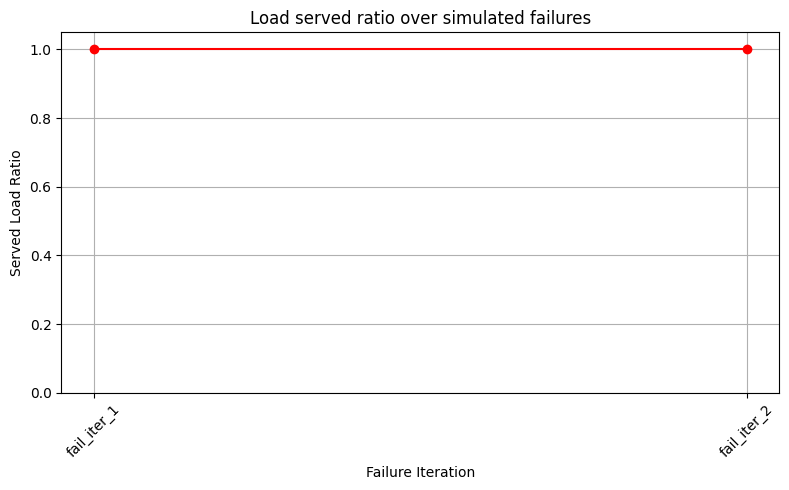

In [ ]:
# 供电比例变化折线图
# 展示：不同失效迭代下，系统中有多少电负载（MW）仍然得到供电。

def plot_served_ratio_over_iterations(results):
    iters = list(results.keys())
    ratios = [results[it]['served_ratio'] for it in iters]

    plt.figure(figsize=(8, 5))
    plt.plot(iters, ratios, marker='o', color='red')
    plt.xticks(rotation=45)
    plt.ylim(0, 1.05)
    plt.ylabel('Served Load Ratio')
    plt.xlabel('Failure Iteration')
    plt.title('Load served ratio over simulated failures')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_served_ratio_over_iterations(results)

In [27]:
# 电压水平箱型图
# 展示：每轮模拟中所有 bus 的电压分布是否仍在正常范围（0.9–1.05 pu）。

def plot_voltage_boxplot(results):
    vm_lists = []
    labels = []

    for it_name, res in results.items():
        try:
            net = res['net']
            if hasattr(net, 'res_bus') and not net.res_bus.empty:
                vm_list = net.res_bus.vm_pu.dropna().tolist()
                if len(vm_list) > 0:
                    vm_lists.append(vm_list)
                    labels.append(it_name)
        except Exception as e:
            print(f"Skip {it_name} due to: {e}")
            continue

    if not vm_lists:
        print("No voltage data available for plotting.")
        return

    plt.figure(figsize=(10, 5))
    plt.boxplot(vm_lists, labels=labels)
    plt.axhline(1.0, color='gray', linestyle='--')
    plt.axhline(0.9, color='red', linestyle='--', label='Undervoltage limit')
    plt.axhline(1.05, color='red', linestyle='--', label='Overvoltage limit')
    plt.ylabel("Voltage magnitude (pu)")
    plt.xlabel("Failure iteration")
    plt.title("Bus voltage distribution per iteration")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_voltage_boxplot(results_dict)

Skip fail_iter_1 due to: 'net'
Skip fail_iter_2 due to: 'net'
No voltage data available for plotting.


C:\Users\mye500\AppData\Local\Temp\ipykernel_14888\1830742442.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged['served'] = merged['served'].fillna(False)
C:\Users\mye500\AppData\Local\Temp\ipykernel_14888\1830742442.py:43: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


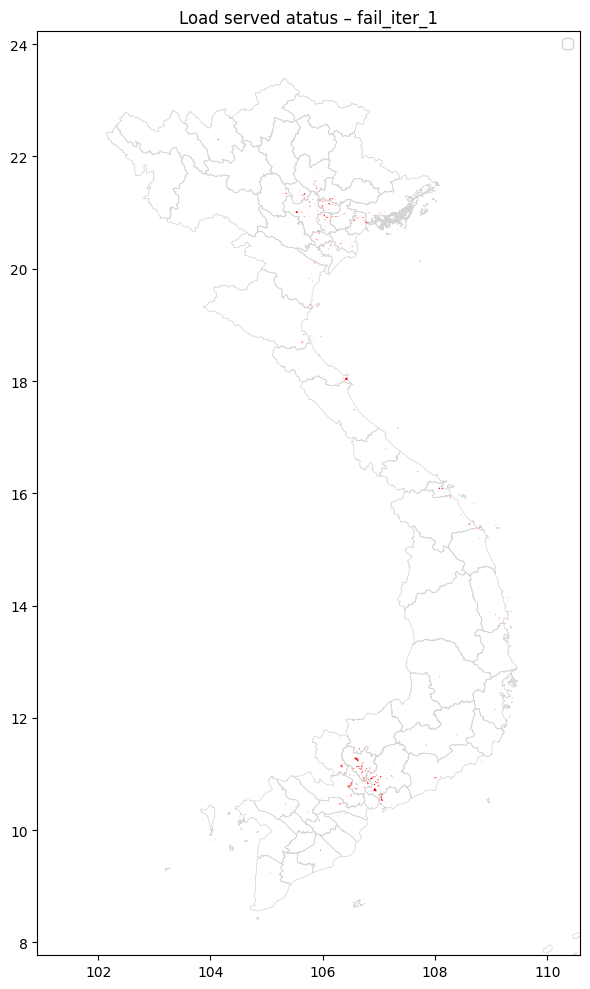

In [ ]:
def plot_failed_loads_map(results_dict, loads_gdf, iteration_name, basemap=None):
    # 容错机制：尝试自动找最接近的 key
    # if iteration_name not in results_dict:
    #     alt_keys = list(results_dict.keys())
    #     close_keys = [k for k in alt_keys if k.replace('_', '') == iteration_name.replace('_', '')]
    #     if close_keys:
    #         print(f"'{iteration_name}' not found. Using closest match: '{close_keys[0]}'")
    #         iteration_name = close_keys[0]
    #     else:
    #         print(f"'{iteration_name}' not found in results.")
    #         return

    # 提取该轮潮流后的供电状态
    load_status_df = results_dict[iteration_name]['load_detail'].copy()
    load_status_df = load_status_df.reset_index().rename(columns={'index': 'osmid'})
    load_status_df['served'] = load_status_df['p_mw'] > 0

    # 合并原始 GeoDataFrame
    merged = loads_gdf.copy()
    merged['osmid'] = merged['osmid'].astype(int)
    merged = merged.merge(load_status_df[['osmid', 'served']], on='osmid', how='left')
    merged['served'] = merged['served'].fillna(False)
    merged = merged.to_crs(epsg=4326)
    
    # 绘图
    fig, ax = plt.subplots(figsize=(6, 10))

    if basemap is not None:
        basemap.to_crs(merged.crs).boundary.plot(ax=ax, color='lightgrey', linewidth=0.5)

    merged[merged['served']].plot(ax=ax, color='green', markersize=10, label='Served')
    merged[~merged['served']].plot(ax=ax, color='red', markersize=10, label='Not Served')

    plt.title(f"Load served atatus – {iteration_name}")
    plt.legend()
    plt.axis('equal')
    plt.xlim(101.5, 110)
    plt.ylim(8, 24)
    plt.tight_layout()
    plt.show()

basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")
plot_failed_loads_map(results_dict, loads_gdf, iteration_name='fail_iter_1', basemap=basemap)

In [ ]:
import plotly.io as pio
from pandapower.plotting.plotly import simple_plotly, pf_res_plotly

# # Plot the network with simple_plotly and save
# fig1 = simple_plotly(net)
# fig1.update_layout(
#     width=1000,
#     height=800,
#     title="Network_parameters_plot",
#     margin=dict(l=10, r=10, t=50, b=10),
# )

# fig1.update_yaxes(scaleanchor="x", scaleratio=1)
# pio.write_html(fig1, file='../figures/Network_parameters_plot_hazards.html', auto_open=False, include_plotlyjs='cdn')

# Plot the network with pf_res_plotly and save
fig2 = pf_res_plotly(net)
fig2.update_layout(
    width=1000,
    height=800,
    title="Network_bus_voltages_and_line_loading",
    margin=dict(l=10, r=10, t=50, b=10),
)
fig2.update_yaxes(scaleanchor="x", scaleratio=1)

pio.write_html(fig2, file='../figures/hazard_figures/Network_bus_voltages_and_line_loading_hazards.html', auto_open=False, include_plotlyjs='cdn')

In [59]:
import matplotlib.pyplot as plt

def plot_full_grid_with_disaster_effects(net, tc_gdf, flood_gdf):
    # Hazard maps
    hazard_union = gpd.GeoSeries(pd.concat([tc_gdf.geometry, flood_gdf.geometry], ignore_index=True)).unary_union

    element_types = ['bus', 'line', 'load', 'gen']
    geodata_suffix = '_geodata'
    all_elements = []

    for etype in element_types:
        table = net[etype]
        geotable_name = etype + geodata_suffix

        if geotable_name not in net:
            continue
        geotable = net[geotable_name]

        df = net[etype].copy()
        # df = df.dropna(subset=['geometry'])
        gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='epsg:32648')
        gdf['type'] = etype
        gdf['net_index'] = gdf.index
        gdf['direct_overlap'] = gdf.geometry.intersects(hazard_union)
        all_elements.append(gdf)

    full_gdf = pd.concat(all_elements, ignore_index=True)

    # 分类 status
    def classify_status(row):
        if row['direct_overlap']:
            return 'direct'
        elif not row['in_service']:
            return 'indirect'
        else:
            return 'active'

    full_gdf['status'] = full_gdf.apply(classify_status, axis=1)

    color_map = {'direct': 'red', 'indirect': 'yellow', 'active': 'green'}
    fig, ax = plt.subplots(figsize=(12, 12))

    for status, color in color_map.items():
        subset = full_gdf[full_gdf['status'] == status]
        if not subset.empty:
            subset.plot(ax=ax, color=color, label=status.capitalize(), 
                        markersize=5 if subset.geom_type.iloc[0] == 'Point' else None)

    tc_gdf.boundary.plot(ax=ax, color='pink', linestyle='--', label='TC')
    flood_gdf.boundary.plot(ax=ax, color='blue', linestyle=':', label='Flood')

    plt.legend()
    plt.axis('equal')
    plt.title("Power grid status with TC effects")
    plt.show()


In [60]:
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString

def plot_grid_with_hazards(net, tc_gdf, flood_gdf=None):
    # 合并所有灾害区域
    hazard_union = gpd.GeoSeries(pd.concat([tc_gdf.geometry, flood_gdf.geometry], ignore_index=True)).unary_union

    # 定义要处理的元素及其 geodata 表
    element_types = ['bus', 'line', 'load', 'gen']
    geodata_suffix = '_geodata'

    all_elements = []

    for etype in element_types:
        table = net[etype]
        geotable_name = etype + geodata_suffix

        if geotable_name not in net:
            continue

        geotable = net[geotable_name]

        # 创建 GeoDataFrame
        if etype in ['bus', 'load', 'gen']:  # 处理为点
            geometry = [Point(xy) for xy in zip(geotable['x'], geotable['y'])]
        elif etype == 'line':  # 处理为线
            geometry = [LineString(coords.coords) for coords in geotable.itertuples(index=False)]

        else:
            continue

        gdf = gpd.GeoDataFrame(table.copy(), geometry=geometry, crs="EPSG:32648")
        gdf['type'] = etype
        gdf['net_index'] = gdf.index
        gdf['direct_overlap'] = gdf.geometry.intersects(hazard_union)

        all_elements.append(gdf)

    # 合并所有元素
    full_gdf = pd.concat(all_elements, ignore_index=True)

    # 设置状态列
    def classify_status(row):
        if row['direct_overlap']:
            return 'direct'
        elif not row['in_service']:
            return 'indirect'
        else:
            return 'active'

    full_gdf['status'] = full_gdf.apply(classify_status, axis=1)

    color_map = {'direct': 'red', 'indirect': 'yellow', 'active': 'green'}
    fig, ax = plt.subplots(figsize=(12, 12))

    for status, color in color_map.items():
        subset = full_gdf[full_gdf['status'] == status]
        if not subset.empty:
            subset.plot(ax=ax, color=color, label=status.capitalize(),
                        markersize=5 if subset.geom_type.iloc[0] == 'Point' else None)

    tc_gdf.boundary.plot(ax=ax, color='pink', linestyle='--', label='TC')
    flood_gdf.boundary.plot(ax=ax, color='blue', linestyle=':', label='Flood')

    plt.legend()
    plt.title("Power grid status under Hazards impacts")
    plt.axis('equal')
    plt.show()

In [61]:
plot_grid_with_hazards(net, tc_gdf)

NameError: name 'tc_gdf' is not defined

In [64]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, shape
from rasterio.features import shapes
import rasterio

def extract_tc_geometry_from_raster(tc_path, speed_threshold=0):
    """
    将 tif 台风路径栅格数据转换为矢量几何
    只提取风速大于阈值的区域
    """
    with rasterio.open(tc_path) as src:
        band = src.read(1)
        mask = band > speed_threshold
        transform = src.transform
        crs = src.crs

        geom_gen = shapes(band, mask=mask, transform=transform)
        geoms = [shape(geom) for geom, val in geom_gen if val > speed_threshold]

    gdf = gpd.GeoDataFrame(geometry=geoms, crs=crs)
    return gdf.to_crs("EPSG:32648")  # 与 net 匹配（UTM）

def plot_grid_with_tc_hazard(net, tc_path, speed_threshold=0):
    # 1. 提取台风影响区域
    tc_gdf = extract_tc_geometry_from_raster(tc_path, speed_threshold)
    hazard_union = tc_gdf.unary_union

    # 2. 电网元素提取
    element_types = ['bus', 'line', 'load', 'gen']
    all_elements = []

    for etype in element_types:
        if etype not in net or f"{etype}_geodata" not in net:
            continue

        table = net[etype]
        geotable = net[f"{etype}_geodata"]

        # 检查数据结构并创建 geometry
        if etype in ['bus', 'load', 'gen']:
            if 'x' in geotable.columns and 'y' in geotable.columns:
                geometry = [Point(xy) for xy in zip(geotable['x'], geotable['y'])]
            else:
                print(f"⚠️ {etype}_geodata missing 'x'/'y'. Skipping.")
                continue
        elif etype == 'line':
            if 'coords' in geotable.columns:
                geometry = [LineString(coords.coords) for coords in geotable.itertuples(index=False)]
            else:
                print(f"⚠️ {etype}_geodata missing 'coords'. Skipping.")
                continue
        else:
            continue

        gdf = gpd.GeoDataFrame(table.copy(), geometry=geometry, crs="EPSG:32648")
        gdf['type'] = etype
        gdf['net_index'] = gdf.index
        gdf['direct_overlap'] = gdf.geometry.intersects(hazard_union)
        all_elements.append(gdf)

    if not all_elements:
        print("❌ No geodata available to plot.")
        return

    full_gdf = pd.concat(all_elements, ignore_index=True)

    def classify_status(row):
        if row['direct_overlap']:
            return 'direct'
        elif not row['in_service']:
            return 'indirect'
        else:
            return 'active'

    full_gdf['status'] = full_gdf.apply(classify_status, axis=1)

    # 3. 绘图
    color_map = {'direct': 'red', 'indirect': 'yellow', 'active': 'green'}
    fig, ax = plt.subplots(figsize=(12, 12))

    for status, color in color_map.items():
        subset = full_gdf[full_gdf['status'] == status]
        if not subset.empty:
            subset.plot(ax=ax, color=color, label=status.capitalize(),
                        markersize=5 if subset.geom_type.iloc[0] == 'Point' else None)

    tc_gdf.boundary.plot(ax=ax, color='blue', linestyle='--', linewidth=1, label='Typhoon Impact Zone')

    plt.legend()
    plt.title("Power Grid Status under Typhoon Impact")
    plt.axis('equal')
    plt.show()


C:\Users\mye500\AppData\Local\Temp\ipykernel_14888\1489719666.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hazard_union = tc_gdf.unary_union


⚠️ load_geodata missing 'x'/'y'. Skipping.
⚠️ gen_geodata missing 'x'/'y'. Skipping.


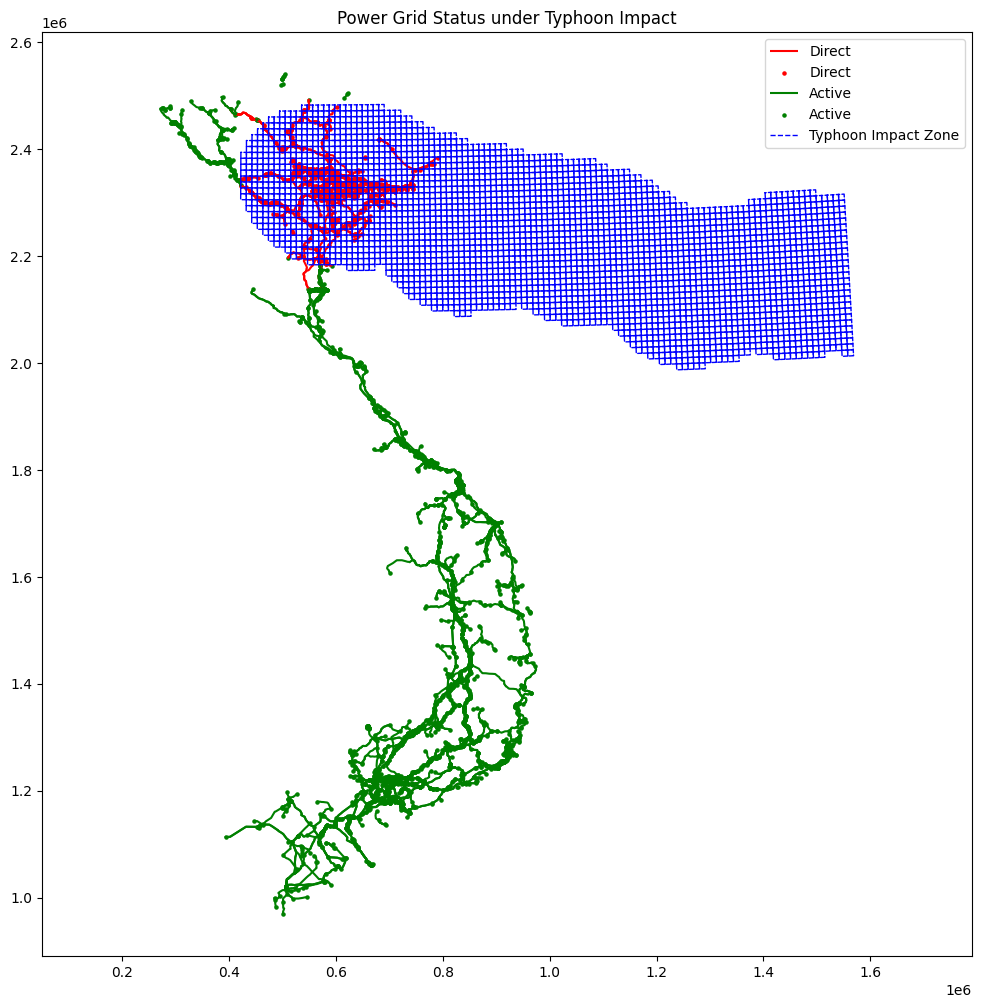

In [65]:
plot_grid_with_tc_hazard(net, tc_path, speed_threshold=17.2)

# OLD!

C:\Users\mye500\AppData\Local\Temp\ipykernel_14888\242485687.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


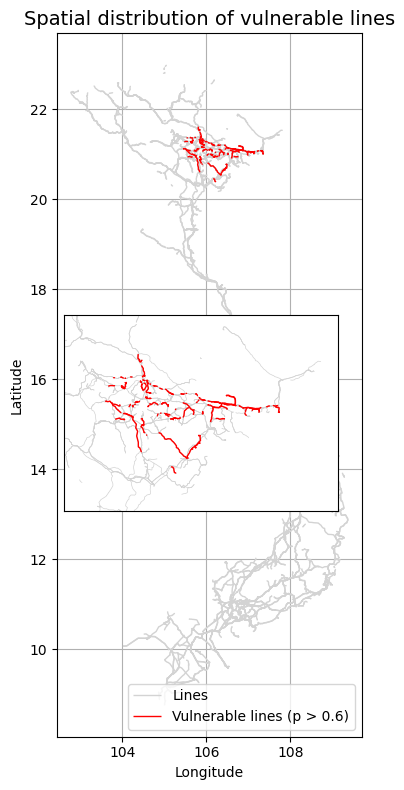

In [21]:
# # 将 simulation_results 转为 GeoDataFrame 进行可视化
# # 计算失效概率（每个元素平均失效率）
# fail_cols = [col for col in simulation_results.columns if col.startswith('fail_iter_')]
# simulation_results['failure_probability'] = simulation_results[fail_cols].mean(axis=1)

# # 选出高风险元素
# vulnerable_gdf = simulation_results[simulation_results['failure_probability'] > 0.6]

# # 画图
# fig, ax_main = plt.subplots(figsize=(10, 8))
# simulation_results.plot(ax=ax_main, color='lightgray', linewidth=1, label='Lines')
# vulnerable_gdf.plot(ax=ax_main, color='red', linewidth=1, label='Vulnerable lines (p > 0.6)')

# ax_main.set_title("Spatial distribution of vulnerable lines", fontsize=14)
# ax_main.set_xlabel("Longitude")
# ax_main.set_ylabel("Latitude")
# ax_main.grid(True)
# ax_main.legend(loc='lower right')

# # 添加小图 inset
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# # 创建 inset axes
# ax_inset = inset_axes(ax_main, width="90%", height="90%", loc='lower left')

# # 设置小图显示内容
# simulation_results.plot(ax=ax_inset, color='lightgray', linewidth=0.5)
# vulnerable_gdf.plot(ax=ax_inset, color='red', linewidth=1)
# ax_inset.set_xlim(105, 108)
# ax_inset.set_ylim(20, 22)
# # ax_inset.set_title("Zoomed-In View", fontsize=10)
# ax_inset.set_xticks([])
# ax_inset.set_yticks([])
# ax_inset.set_facecolor('white')

# plt.tight_layout()
# plt.savefig("../figures/vulnerable_elements_map_with_inset.png")
# plt.show()

# from PIL import Image
# Image.open("../figures/vulnerable_elements_map_with_inset.png").show()

C:\Users\mye500\AppData\Local\Temp\ipykernel_14888\4265481848.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


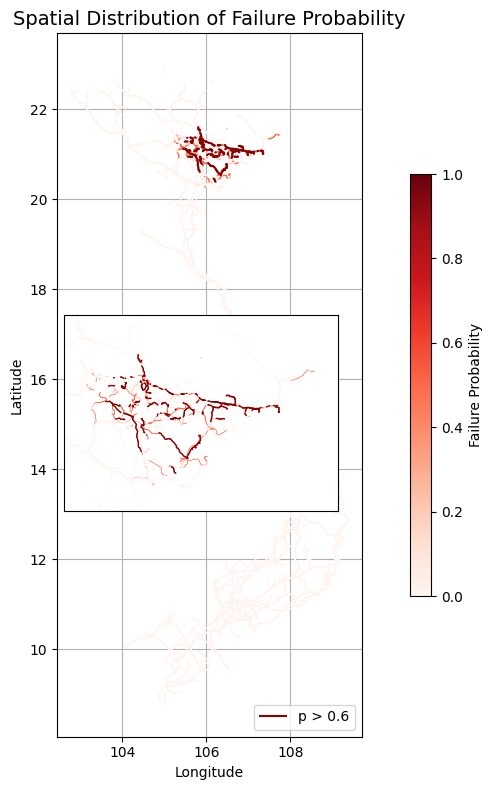

In [30]:
# # 1. 计算 failure_probability
# fail_cols = [col for col in simulation_results.columns if col.startswith('fail_iter_')]
# simulation_results['failure_probability'] = simulation_results[fail_cols].mean(axis=1)

# # 2. 选出高风险元素用于描边或标记
# vulnerable_gdf = simulation_results[simulation_results['failure_probability'] > 0.6]

# # 3. 设置 colormap（红色系渐变）
# cmap = plt.cm.Reds
# norm = mcolors.Normalize(vmin=0, vmax=1)

# # 4. 开始绘图
# fig, ax_main = plt.subplots(figsize=(10, 8))

# # 4.1 所有元素：使用 failure_probability 渐变色
# simulation_results.plot(ax=ax_main,
#                         column='failure_probability',
#                         cmap=cmap,
#                         linewidth=1,
#                         legend=True,
#                         norm=norm,
#                         legend_kwds={'label': "Failure probability", 'shrink': 0.6})

# # 4.2 高风险元素额外描边（可选）
# if not vulnerable_gdf.empty:
#     vulnerable_gdf.plot(ax=ax_main, edgecolor='darkred', facecolor='none', linewidth=1.5, label='p > 0.6')

# # 5. 设置主图样式
# # ax_main.set_title("Spatial Distribution of Failure Probability", fontsize=14)
# ax_main.set_xlabel("Longitude")
# ax_main.set_ylabel("Latitude")
# ax_main.grid(True)
# ax_main.legend(loc='lower right')

# # 6. 添加 inset
# ax_inset = inset_axes(ax_main, width="90%", height="90%", loc='lower left')
# simulation_results.plot(ax=ax_inset,
#                         column='failure_probability',
#                         cmap=cmap,
#                         linewidth=0.5,
#                         norm=norm)

# if not vulnerable_gdf.empty:
#     vulnerable_gdf.plot(ax=ax_inset, edgecolor='darkred', facecolor='none', linewidth=1)

# # zoom范围自定义
# ax_inset.set_xlim(105, 108)
# ax_inset.set_ylim(20, 22)
# ax_inset.set_xticks([])
# ax_inset.set_yticks([])
# ax_inset.set_facecolor('white')

# plt.tight_layout()
# plt.savefig("../figures/vulnerable_elements_map_with_gradient.png", dpi=300)
# plt.show()

# # 显示保存的图像
# Image.open("../figures/vulnerable_elements_map_with_gradient.png").show()
